# 2026-03-14 TODO

|TODO|내용|비고|구현 일시|
|:---:|:---:|:---:|:---:|
|[x]|1. 의미적 문단(Semantic Paragraph) 자동 생성||2026/03/14-2026/03/NN|
|[x]|2. 의미적 문단(Semantic Paragraph) 기반 시각화||2026/03/14-2026/03/NN|

~~연구실 가고 싶어요~~

[Stage 5] 의미적 문단(Semantic Paragraph) 자동 생성
단순히 문장을 나열하는 것이 아니라, SQL 데이터를 기반으로 심리적 의미가 완결되는 단위를 묶어야 합니다.

SQL 작업: 동일한 File_Code와 Session_No 내에서 문장 간 KM-BERT 유사도가 급격히 떨어지는 지점을 찾아 '문단 ID'를 부여합니다.

목적: 화자가 한 가지 주제(예: 과거의 트라우마)에 대해 얼마나 지속적으로, 혹은 파편적으로 발화하는지 측정하기 위함입니다.

In [1]:
# 기본 라이브러리 및 GCP BigQuery 클라이언트 임포트
import pandas as pd
import numpy as np
from google.cloud import bigquery
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# BigQuery 클라이언트 초기화
# 환경변수에 GOOGLE_APPLICATION_CREDENTIALS가 설정되어 있어야 합니다.
from google.oauth2 import service_account

key_path = '/workspaces/Psychological-counseling-researching/.key/testprojects-453622-d1f78fcce8b7.json'
credentials = service_account.Credentials.from_service_account_file(key_path)

client = bigquery.Client(credentials=credentials, project=credentials.project_id)
print(f"Client created with project: {client.project}")

# 데이터 로드 (morpheme_classification_kmbert_embedding 테이블)
# 실제 환경에 맞춰 테이블명과 스키마를 확인해야 합니다.
query = """
    SELECT 
        file_code, 
        session_no, 
        timeline_index, 
        split_row_index, 
        split_contents, 
        content_embedding
    FROM 
        `testprojects-453622.Psychological_counseling_data.morpheme_classification_kmbert_embedding`
    ORDER BY 
        file_code, session_no, timeline_index, split_row_index
"""
df = client.query(query).to_dataframe()

print("KM-BERT 임베딩 데이터를 불러왔습니다.")


Client created with project: testprojects-453622
KM-BERT 임베딩 데이터를 불러왔습니다.


In [2]:
def calculate_semantic_paragraphs(df, threshold=0.6):
    """
    동일한 file_code와 session_no 내에서 이전 문장과의 KM-BERT 임베딩 코사인 유사도를 계산하고,
    유사도가 threshold보다 낮으면(급격히 떨어지면) 새로운 문단 ID를 부여합니다.
    """
    
    # 문단 ID를 저장할 리스트
    paragraph_ids = []
    current_paragraph_id = 1
    previous_embedding = None
    
    # 코사인 유사도를 계산할 임시 리스트
    similarities = [np.nan] * len(df)
    
    # 데이터프레임을 그룹화하여 각 세션/파일별로 처리
    grouped = df.sort_values(by=['file_code', 'session_no', 'timeline_index', 'split_row_index'])
    
    for idx, row in grouped.iterrows():
        # 파일이나 세션이 변경되면 문단 ID 초기화
        # 이 부분은 단순화를 위해 단순히 순차적 할당하는 것으로 처리
        current_embedding = np.array(row['content_embedding']).reshape(1, -1)
        
        if previous_embedding is not None and row['file_code'] == prev_file_code and row['session_no'] == prev_session_no:
            # 코사인 유사도 계산
            similarity = cosine_similarity(previous_embedding, current_embedding)[0][0]
            similarities[idx] = similarity
            
            # 유사도가 임계값 미만이면 주제가 전환되었다고 판단하여 문단 ID 증가
            if similarity < threshold:
                current_paragraph_id += 1
        else:
            # 새로운 파일이나 세션이 시작될 때
            current_paragraph_id = 1
            similarities[idx] = 1.0 # 첫 문장은 유사도 1로 간주
            
        # 문단 ID 리스트에 추가
        paragraph_ids.append(current_paragraph_id)
        
        # 현재 상태를 이전 상태로 업데이트
        previous_embedding = current_embedding
        prev_file_code = row['file_code']
        prev_session_no = row['session_no']
        
    df['paragraph_id'] = [x for _, x in sorted(zip(grouped.index, paragraph_ids))]
    df['semantic_similarity_with_prev'] = similarities
    
    return df

In [3]:
threshold = 0.6 # 유사도 임계점 (테스트를 통해 적절한 값 도출 필요)
result_df = calculate_semantic_paragraphs(df, threshold)
print(result_df[['file_code', 'split_contents', 'semantic_similarity_with_prev', 'paragraph_id']].head(20))


   file_code                                     split_contents  \
0       A008                                          선생님반갑습니다.   
1       A008   저희이제선생님하고8회기동안상담을진행하게될거이고요.저는@COUNSELOR이라고합니다.   
2       A008                                             반갑습니다.   
3       A008                                      @NAME선생님맞으시죠?   
4       A008                              저가혹시호칭은선생님이라고부르면될까요?   
5       A008                                  아니면원하시는호칭이있으실까요?   
6       A008                                  편한대로부르면.뭐가편할까요?   
7       A008                          학교에서선생님이라는호칭그래도익숙하시지않으세요?   
8       A008                                             어떻으세요?   
9       A008                                         요즘은그런것같어요.   
10      A008  그래도좀익숙하신호칭으로부르면그래도조금더편안하지않을까싶어서저도선생님이라고부르도록하겠...   
11      A008                   네,여기지금스크리닝된결과지를보니까중독에체크가되어있으세요.   
12      A008  그런데선생님께서여기보면나쁜습관고치기진로의확신을얻을수있는조언에대하어서이제상담받고싶은...   
13      A008                         지금그리고선생님직업에@TITLE이라고하시었네요

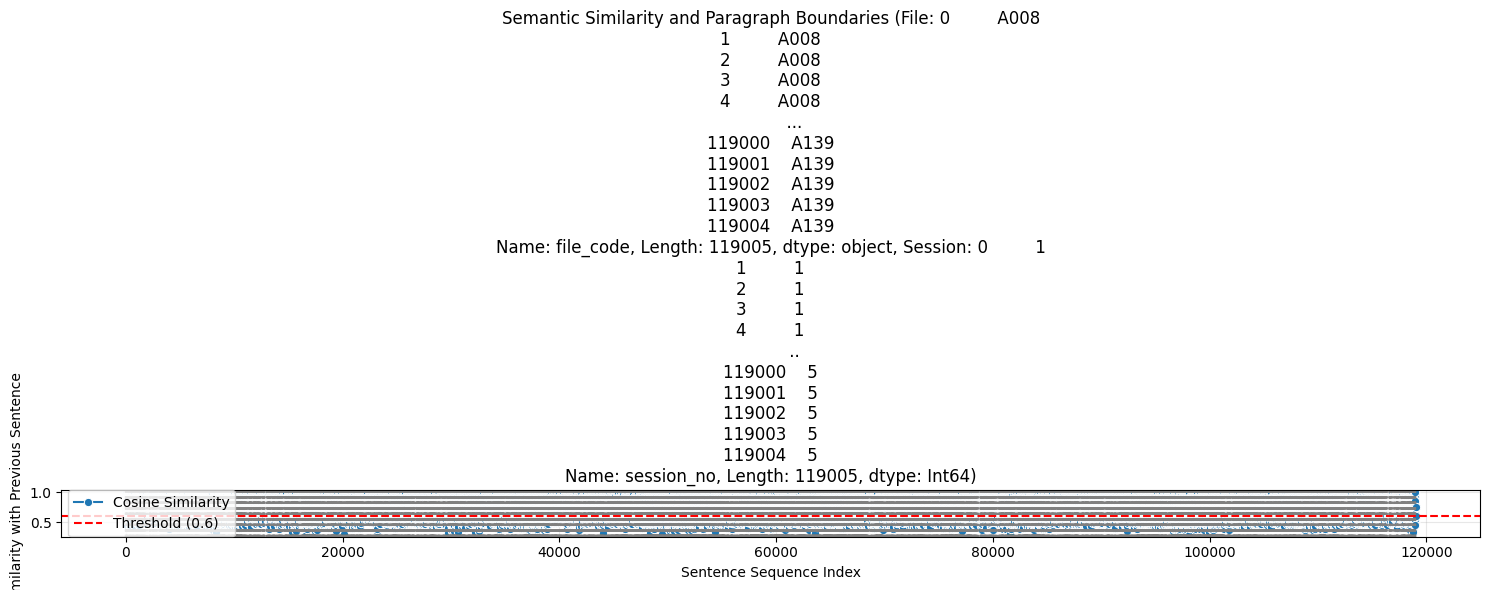

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화할 샘플 데이터 선택 (데이터프레임 내의 첫 번째 파일 및 세션)
if not result_df.empty:
    sample_file_code = result_df['file_code']
    sample_session_no = result_df['session_no']
    
    sample_df = result_df[(result_df['file_code'] == sample_file_code) & 
                          (result_df['session_no'] == sample_session_no)].copy()
    
    # 문장 순서대로 인덱스 재부여
    sample_df.reset_index(drop=True, inplace=True)
    
    plt.figure(figsize=(15, 6))
    
    # 1. 문장 간 유사도 선 그래프 그리기
    sns.lineplot(data=sample_df, x=sample_df.index, y='semantic_similarity_with_prev', 
                 marker='o', label='Cosine Similarity')
    
    # 임계값(Threshold) 선 표시
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
    
    # 2. 문단이 변경되는 지점 (새로운 paragraph_id가 시작되는 곳)에 수직선 표시
    boundary_indices = sample_df[sample_df['paragraph_id'].diff() != 0].index.tolist()
    
    # 첫 번째 문장은 제외
    if 0 in boundary_indices:
        boundary_indices.remove(0)
        
    for idx in boundary_indices:
        plt.axvline(x=idx - 0.5, color='gray', linestyle=':', alpha=0.7)
        
    plt.title(f'Semantic Similarity and Paragraph Boundaries (File: {sample_file_code}, Session: {sample_session_no})')
    plt.xlabel('Sentence Sequence Index')
    plt.ylabel('Cosine Similarity with Previous Sentence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("데이터가 존재하지 않습니다.")